# MANTA - Preprocessing

This notebook prepares two tissue slices to be aligned by MANTA.

In [1]:
import anndata as ad
import manta

# I/O
from pathlib import Path

/home/matthias/anaconda3/envs/manta/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/matthias/anaconda3/envs/manta/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
%load_ext autoreload
%autoreload 2
%env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


## File Inputs

The first step is to read in the `h5ad` files with `ad.read_h5ad`, which will read in the tissue slices in the AnnData format. The **source** is the tissue slice that will be aligned to the **target** slice.  

In [ ]:
# "/staging/leuven/stg_00002/lcb/lcb_projects/SPF/mkovacic/data/dataset_MOUSE_BRAIN"
data_dir = Path("/mnt/c/Users/matth/Desktop/MANTA/MOUSE_BRAIN/")

In [4]:
source = ad.read_h5ad(data_dir / "slice_75.h5ad")
target = ad.read_h5ad(data_dir / "slice_76.h5ad")

## Preprocessing

Before the slices can be aligned they need to be preprocessed. This entails the following steps:

1. Correcting batch-effects
2. Computing the PCA and NMF embeddings
3. Computing the set of genes present in both tissues (if tissue slices originate from different ST technologies)

**NOTE**: *All slices are required to store both their spatial information and gene names under the same key. If these differ between slices, make sure to manually correct this first.*

In [5]:
adatas = manta.preprocessing.preprocess(
    source=source,
    target=target,
    gene_key="gene_name",
    spatial_key="X_spatial_coords"
)

Finished: 100%|██████████| 6/6 [00:25<00:00,  4.27s/it]                


In [6]:
source = adatas[0]
target = adatas[1]

After preprocessing, we can visualize where the slices are located relative to each other using `manta.plot.spatial`.

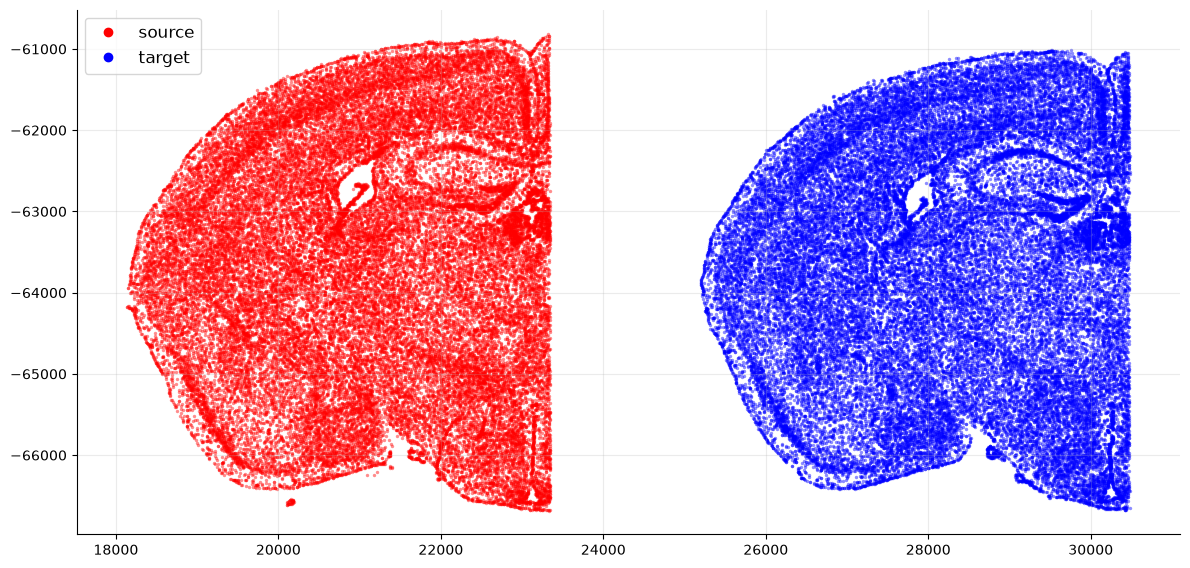

In [7]:
manta.plot.spatial(
    adatas=adatas,
    labels=["source", "target"],
    colors=["red", "blue"],

    figsize=(12,12),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

## Sampling

**NOTE**: *This step is only required for non-rigid alignment.*

Since an alignment does not necessarily need all spatial observations, the tissue slices can be (sub)sampled. The `manta.sampling.sample` function can produce three different samplings:

* `importance`: samples observations based on the local density of observations (see later). Higher-density areas will be sampled more frequently. 
* `stratified`: samples observations by voxelizing the observations.
* `fps`: samples observations based on the furthest-point-sampling algorithm.

Depending on the type of tissues and the misalignment between them, different sampling routines may be preferred.

In [8]:
import torch

print("PyTorch:", torch.__version__)
print("PyTorch CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

PyTorch: 2.14.0+cu130
PyTorch CUDA: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
Capability: (12, 0)


In [9]:
manta.sampling.sample(
    adatas=adatas,
    sampler="importance",
    fraction=0.25,
    bin_size=128,
    spatial_key="spatial_manta"
)

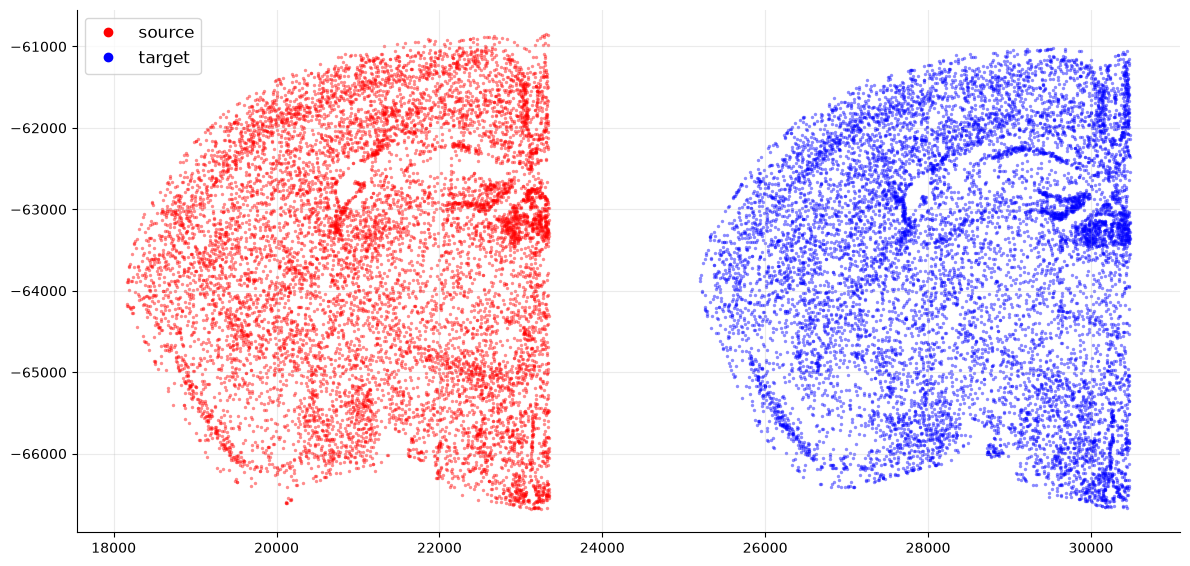

In [10]:
manta.plot.sampling(
    adatas=adatas,
    labels=["source", "target"],
    colors=["red", "blue"],
    sampling_key="sampling",

    figsize=(12,12),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

The following cell shows what the density (and its derivative) of the source tissue looks like. As expected, regions with more observations exhibit a higher density.

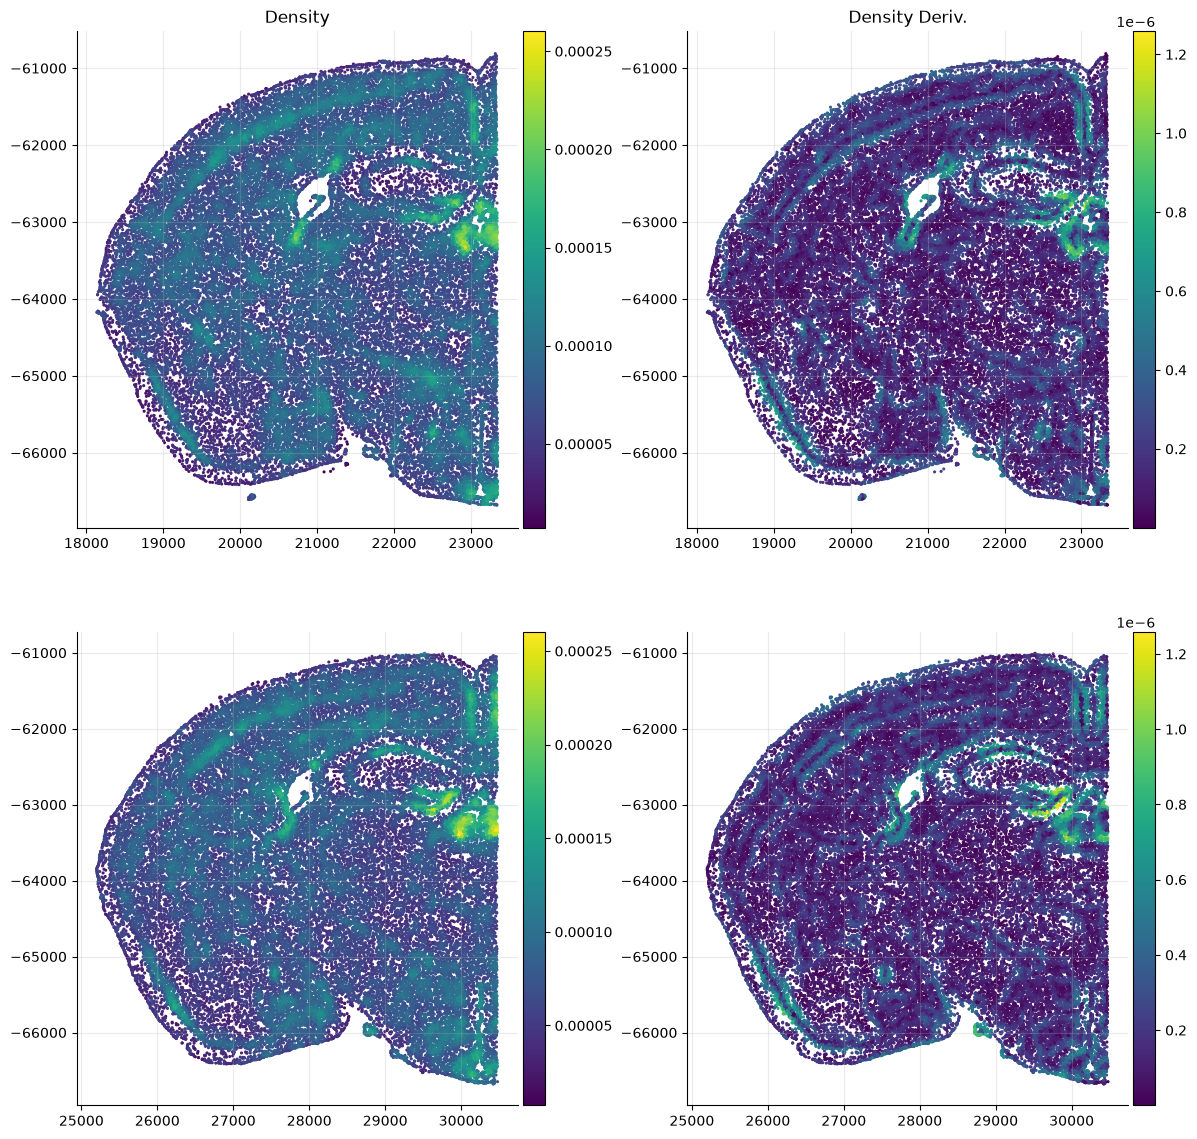

In [11]:
manta.plot.density(
    adatas=adatas,
    labels=["source", "target"],
    density_key="rho_128",

    figsize=(12,12),
    marker_size=5,
    equal_aspect=True
)

## Next Steps

This concludes the required preprocessing steps in aligning two tissue slices in MANTA. The next notebook, `rigid_alignment.ipynb` will cover the steps required in order to perform a rigid alignment.